In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(rc={'figure.figsize': [20, 5]}, font_scale=.90)

import nltk
#pyo.init_notebook_mode()
import re
import string
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import defaultdict
pd.set_option('display.max_columns', None)

plt.rc('figure',figsize=(17,13))
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as pyo
from plotly.subplots import make_subplots

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/kaggle/input/dataset-accessibility-user-reviews/VADER_A11y_Labels.csv
/kaggle/input/dataset-accessibility-user-reviews/TextBlob_A11y_Labels.csv


<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: #ADD8E6;"><b style="color:black;">VADER (Valence Aware Dictionary and sEntiment Reasoner)</b></h1></center>

VADER Sentiment Analysis :

'VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media. VADER uses a combination of A sentiment lexicon is a list of lexical features (e.g., words) which are generally labeled according to their semantic orientation as either positive or negative. VADER not only tells about the Positivity and Negativity score but also tells us about how positive or negative a sentiment is."

https://www.geeksforgeeks.org/python-sentiment-analysis-using-vader/

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT1fdNJu8vflrjAvCVP2ZZO_r46fFU7nJdwag&usqp=CAU)javacodemonk.com

In [3]:
!pip install vaderSentiment
!pip install twython

     |████████████████████████████████| 125 kB 279 kB/s eta 0:00:01


In [4]:
data = pd.read_csv("/kaggle/input/dataset-accessibility-user-reviews/VADER_A11y_Labels.csv", delimiter=',', encoding='ISO-8859-2')
data.head()

,desc_id,source_name,review_text,is_accessibility,cleanText,Vader Score,Vader Sentiment
0,1,gp_AOqpTOE-4PtpSwSKzv8CF6EtR6seFSLwg-QQPTpQKze...,Excellent app. Been using it for years on man...,Accessibility Review,excellent app using years many different phone...,0.8807,Positive
1,1,gp_AOqpTOGPKJI_1QuwFgSTcvd7BanaHdhJoLUXZDx8OVt...,I've used this on a different phone - but cur...,Accessibility Review,used different phone currently moto android re...,0.8271,Positive
2,1,lg_AOqpTOE5_m1p9SEdAbCNs_Nh_qN7EHMLnyPnytEW9NX...,Fantastic program! Instant search results and...,Accessibility Review,fantastic program instant search results fast ...,0.9670,Positive
3,1,lg_AOqpTOEyZAX-Z1qAqVvbqV8s6vJAttZvFBFixQTM_jW...,I'm using this on my mobile as well as on PC ...,Accessibility Review,using mobile well view offline dictionaries us...,0.9169,Positive
4,1,gp_AOqpTOE6SfnT_RCAb9w8AbMpASAbJDvsJIHxp_xuhKg...,Text reflow doesn't work. I want my money back...,Accessibility Review,text reflow work want money back,0.0772,Positive


TEXT PREPROCESSING FOR VADER SENTIMENT ANALYSIS

"Here we don't touch punctuations and case for now as VADER SENTIMENT ANALYSIS SCORES are affected by factors like punctuations,capitalization,preceeding-trigrams,degree modifiers,conjunctions etc."

"The Sentiments have been classified based on scores according to the VADER convention.
A new column 'Sentiment'is thus, added giving sentiment corresponding to each Tweet text."

In [5]:
#To avoid below TypeError: expected string or bytes-like object
#https://stackoverflow.com/questions/43727583/re-sub-erroring-with-expected-string-or-bytes-like-object

data['review_text']=data['review_text'].apply(str)

In [6]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

def clean(text):
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('<.*?>+', '', text)
    return text
    


data['review_text'] = data['review_text'].apply(lambda x:clean(x))
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()
scores=[]
for i in range(len(data['review_text'])):
    
    score = analyser.polarity_scores(data['review_text'][i])
    score=score['compound']
    scores.append(score)
sentiment=[]
for i in scores:
    if i>=0.05:
        sentiment.append('Positive')
    elif i<=(-0.05):
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')
data['sentiment']=pd.Series(np.array(sentiment))

In [7]:
data.head(2)

,desc_id,source_name,review_text,is_accessibility,cleanText,Vader Score,Vader Sentiment,sentiment
0,1,gp_AOqpTOE-4PtpSwSKzv8CF6EtR6seFSLwg-QQPTpQKze...,Excellent app. Been using it for years on many...,Accessibility Review,excellent app using years many different phone...,0.8807,Positive,Positive
1,1,gp_AOqpTOGPKJI_1QuwFgSTcvd7BanaHdhJoLUXZDx8OVt...,I've used this on a different phone - but cur...,Accessibility Review,used different phone currently moto android re...,0.8271,Positive,Positive


#I think I didn't need to make that above since I had Vader Sentiment since the very beginning.

(-0.5, 399.5, 199.5, -0.5)

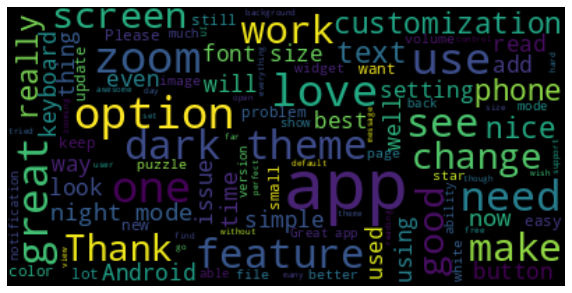

In [8]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

from wordcloud import WordCloud, STOPWORDS , ImageColorGenerator

tweet_All = " ".join(review for review in data.review_text)


fig, ax = plt.subplots(1, 1, figsize  = (10,10))
# Create and generate a word cloud image:
wordcloud_ALL = WordCloud(max_font_size=50, max_words=100, background_color="black").generate(tweet_All)

# Display the generated image:
ax.imshow(wordcloud_ALL, interpolation='bilinear')

ax.axis('off')

#Removing Punctuations and making text lowercase

In [9]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

def clean_text(text):
    
    text = str(text).lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    
    return text
data['review_text'] = data['review_text'].apply(lambda x:clean_text(x))

In [10]:
data['review_text']

0       excellent app been using it for years on many ...
1        ive used this on a different phone  but curre...
2        fantastic program instant search results and ...
3        im using this on my mobile as well as on pc t...
4           text reflow doesnt work i want my money back 
                              ...                        
2658     like the simplicity of this app and the dark ...
2659    very nice thanks for the open source calendar ...
2660                          a dark theme would be great
2661    too barebone  no way to set font size and no r...
2662                      would love to see a dark theme 
Name: review_text, Length: 2663, dtype: object

#STEMMING AND LEMMATIZATION

df shows the text at each step of the preprocessing
From the dataframe df we can decide which one of the stemming(Porter or Snowball)/lemmatization or both is suitable for our data.

In [11]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

df=pd.DataFrame()
df['review_text']=data['review_text']
def tokenization(text):
    text = re.split('\W+', text)
    return text

df['tokenized'] = df['review_text'].apply(lambda x: tokenization(x.lower()))
stopword = nltk.corpus.stopwords.words('english')
def remove_stopwords(text):
    text = [word for word in text if word not in stopword]
    return text
    
df['No_stopwords'] = df['tokenized'].apply(lambda x: remove_stopwords(x))

ps = nltk.PorterStemmer()

def stemming1(text):
    text = [ps.stem(word) for word in text]
    return text

df['stemmed_porter'] = df['No_stopwords'].apply(lambda x: stemming1(x))

from nltk.stem.snowball import SnowballStemmer
s_stemmer = SnowballStemmer(language='english')
def stemming2(text):
    text = [s_stemmer.stem(word) for word in text]
    return text
df['stemmed_snowball'] = df['No_stopwords'].apply(lambda x: stemming2(x))

wn = nltk.WordNetLemmatizer()

def lemmatizer(text):
    text = [wn.lemmatize(word) for word in text]
    return text

df['lemmatized'] = df['No_stopwords'].apply(lambda x: lemmatizer(x))

In [12]:
df.head(2)

,review_text,tokenized,No_stopwords,stemmed_porter,stemmed_snowball,lemmatized
0,excellent app been using it for years on many ...,"[excellent, app, been, using, it, for, years, ...","[excellent, app, using, years, many, different...","[excel, app, use, year, mani, differ, phone, a...","[excel, app, use, year, mani, differ, phone, a...","[excellent, app, using, year, many, different,..."
1,ive used this on a different phone but curre...,"[, ive, used, this, on, a, different, phone, b...","[, ive, used, different, phone, currently, mot...","[, ive, use, differ, phone, current, moto, g, ...","[, ive, use, differ, phone, current, moto, g, ...","[, ive, used, different, phone, currently, mot..."


In [13]:
data['review_text']=df['lemmatized']
data.head(2)

,desc_id,source_name,review_text,is_accessibility,cleanText,Vader Score,Vader Sentiment,sentiment
0,1,gp_AOqpTOE-4PtpSwSKzv8CF6EtR6seFSLwg-QQPTpQKze...,"[excellent, app, using, year, many, different,...",Accessibility Review,excellent app using years many different phone...,0.8807,Positive,Positive
1,1,gp_AOqpTOGPKJI_1QuwFgSTcvd7BanaHdhJoLUXZDx8OVt...,"[, ive, used, different, phone, currently, mot...",Accessibility Review,used different phone currently moto android re...,0.8271,Positive,Positive


In [14]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

temp = data.groupby('Vader Sentiment').count()['review_text'].reset_index().sort_values(by='review_text',ascending=False)
temp.style.background_gradient(cmap='Purples')

,Vader Sentiment,review_text
2,Positive,2112
0,Negative,286
1,Neutral,265


#Above, the original code was Sentiment. Since we already have Vader Sentiment in the feature/columns I kept it.

In [15]:
temp = temp.rename(columns={'Vader Sentiment':'sentiment', 'review_text': 'text'})

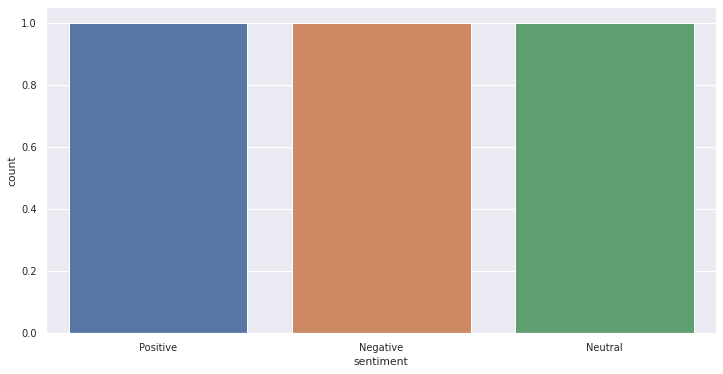

In [16]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

plt.figure(figsize=(12,6))
sns.countplot(x='sentiment',data=temp)
#fig = go.Figure(go.Funnelarea(
 #   text =temp.sentiment,
  #  values = temp.text,
   # title = {"position": "top center", "text": "Funnel-Chart of Sentiment Distribution"}
    #))  #Draft session error with Plotly 
fig.show()

#To avoid error below : "number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of ticklabels (3)

I changed ys = range(1,5)Original code
to ys = range(1,4)

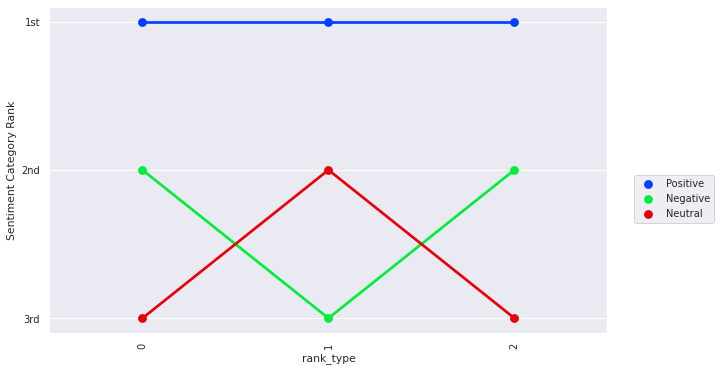

In [17]:
#Code by  Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

genre_difference_metric = [data['Vader Sentiment'].value_counts().index,data.groupby(['Vader Sentiment']).sum()['Vader Score'].sort_values(ascending=False).index,data.groupby(['Vader Sentiment']).sum()['desc_id'].sort_values(ascending=False).index]

#Dataframe to be used for plotting.
genre_evolution_df = pd.DataFrame(columns=['genre', 'rank_type', 'rank'])

#Populate the dataframe
for metric in range(3):
    for genre in range(len(genre_difference_metric[metric])):
        genre_evolution_df = genre_evolution_df.append({'genre':genre_difference_metric[metric][genre], 'rank_type': metric, 'rank':genre},
                                   ignore_index=True)
plt.style.use('seaborn-bright')       
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

    

ax.set_xlim([-2,4])
xs = [0.0, 1.0, 2.0]
x_labels = ['Vader Sentiment count', 'sum of Vader Score', 'sum of desc_id']
plt.xticks(range(len(xs)), x_labels)
plt.xticks(xs, x_labels, rotation='vertical')
sns.pointplot(x=genre_evolution_df.rank_type,
              y=3-genre_evolution_df['rank'], 
              hue=genre_evolution_df.genre)
ys = range(1,4)#To avoid he number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of ticklabels (3)
y_labels = ['3rd', '2nd', '1st']
plt.yticks(ys, y_labels)  
ax.set_ylabel('Sentiment Category Rank')

plt.legend(bbox_to_anchor=(0.7,0., 0.5, 0.5),loc='best',ncol=1)
plt.show(); 

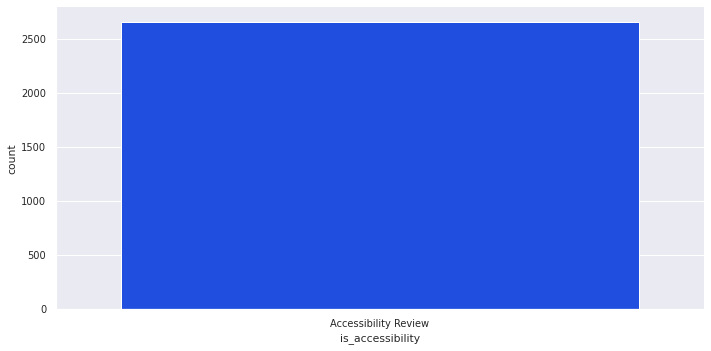

In [18]:
sns.catplot(data=data, x='is_accessibility', kind= 'count',height=5,aspect=2);

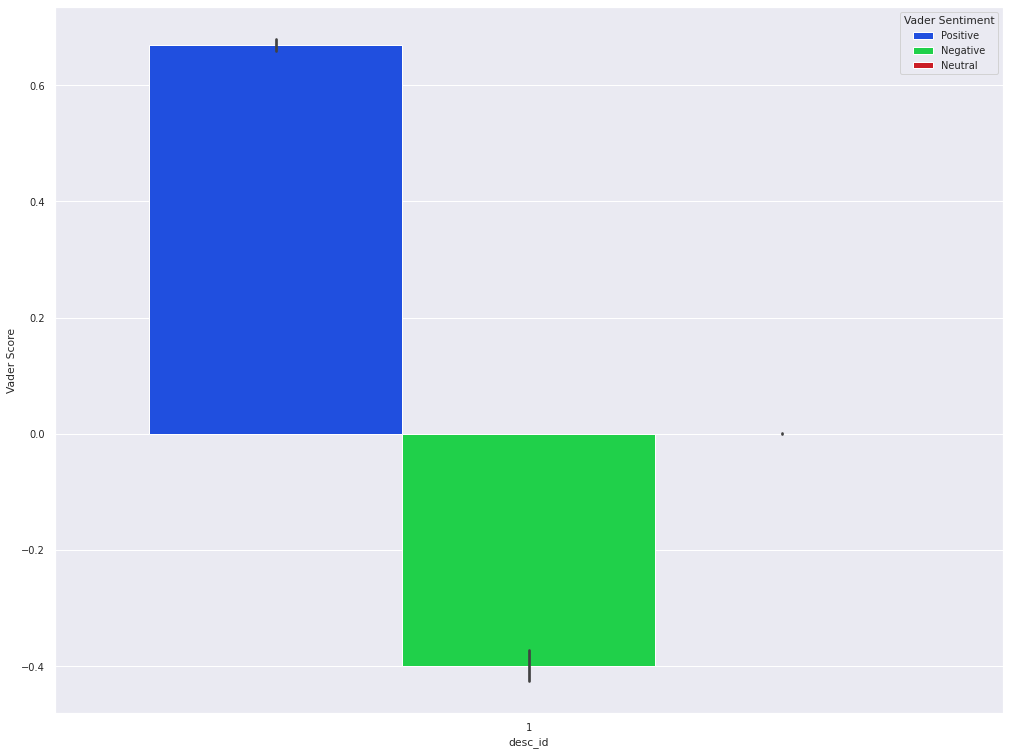

In [19]:
sns.barplot(x="desc_id", y="Vader Score", hue="Vader Sentiment", data=data);

In [20]:
#Code by https://www.geeksforgeeks.org/python-sentiment-analysis-using-vader/

# import SentimentIntensityAnalyzer class
# from vaderSentiment.vaderSentiment module.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
# function to print sentiments
# of the sentence.
def sentiment_scores(sentence):
 
    # Create a SentimentIntensityAnalyzer object.
    sid_obj = SentimentIntensityAnalyzer()
 
    # polarity_scores method of SentimentIntensityAnalyzer
    # object gives a sentiment dictionary.
    # which contains pos, neg, neu, and compound scores.
    sentiment_dict = sid_obj.polarity_scores(sentence)
     
    print("Overall sentiment dictionary is : ", sentiment_dict)
    print("sentence was rated as ", sentiment_dict['neg']*100, "% Negative")
    print("sentence was rated as ", sentiment_dict['neu']*100, "% Neutral")
    print("sentence was rated as ", sentiment_dict['pos']*100, "% Positive")
 
    print("Sentence Overall Rated As", end = " ")
 
    # decide sentiment as positive, negative and neutral
    if sentiment_dict['compound'] >= 0.05 :
        print("Positive")
 
    elif sentiment_dict['compound'] <= - 0.05 :
        print("Negative")
 
    else :
        print("Neutral")
 
 
   
# Driver code
if __name__ == "__main__" :
 
    print("\n1st statement :")
    sentence = "text reflow doesnt work i want my money back."
 
    # function calling
    sentiment_scores(sentence)
 
    print("\n2nd Statement :")
    sentence = "like the simplicity of this app and the dark"
    sentiment_scores(sentence)
 
    print("\n3rd Statement :")
    sentence = "too barebone  no way to set font size and no r."
    sentiment_scores(sentence)


1st statement :
Overall sentiment dictionary is :  {'neg': 0.133, 'neu': 0.867, 'pos': 0.0, 'compound': -0.0572}
sentence was rated as  13.3 % Negative
sentence was rated as  86.7 % Neutral
sentence was rated as  0.0 % Positive
Sentence Overall Rated As Negative

2nd Statement :
Overall sentiment dictionary is :  {'neg': 0.0, 'neu': 0.762, 'pos': 0.238, 'compound': 0.3612}
sentence was rated as  0.0 % Negative
sentence was rated as  76.2 % Neutral
sentence was rated as  23.799999999999997 % Positive
Sentence Overall Rated As Positive

3rd Statement :
Overall sentiment dictionary is :  {'neg': 0.328, 'neu': 0.672, 'pos': 0.0, 'compound': -0.5267}
sentence was rated as  32.800000000000004 % Negative
sentence was rated as  67.2 % Neutral
sentence was rated as  0.0 % Positive
Sentence Overall Rated As Negative


#Acknowledgment:

Shreya Sajal https://www.kaggle.com/shreyasajal/pfizer-vaccine-tweets-vader-sentiment-analysis-eda

"We need a Female Darth Vader Scientist 

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQQjV4VXBiGNklbK4MA61W74CIwMsmfvPvDfA&usqp=CAU)m.facebook.com